In [5]:
import math
import random

In [ ]:
#Bu haftanın görevi:

#1. Python ile tek nöron forward pass yaz, kütüphane kullanmadan. (1. video)
#2. Birden fazla nörondan oluşan küçük bir katman kur, forward pass'i buna genişlet. (1. video)
#3. Basit bir loss fonksiyonu yaz. (2. video)
#4. Parametreleri manuel değiştirerek loss'un nasıl değiştiğini gözlemle, loss eğrisini çiz. (2. video)
#5. Sayısal türev (numerical derivative) ile basit bir gradient descent döngüsü kur: parametreyi küçük adımlarla güncelleyerek loss'u düşür. (2. ve 3. video)

In [ ]:
#ADIM 1 - tekil nöron ve tekil katman

In [6]:
#sigmoid fonksiyonu
def sigmoid(x):
    return (1 / (1 + math.exp(-x)))

In [198]:
#Neuron sınıfı
class Neuron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def forward(self, inputs):
        if len(inputs) != len(self.weights):
            return True
        weighted_sum = sum(numb * weight for numb, weight in zip(inputs, self.weights)) + self.bias
        return sigmoid(weighted_sum)        
        
        

In [247]:
# Neuron test
n_weights = [random.randint(-1, 1) for _ in range(3)]
n_bias = random.uniform(-1, 1)
n = Neuron(n_weights, n_bias)
n.weights, n.bias

([1, -1, 1], -0.7885982933322992)

In [203]:
#Layer Sınıfı
class Layer:
    def __init__(self, weights_list, biases_list):
        self.neurons = list(Neuron(w, b) for w, b in zip(weights_list, biases_list))
    def forward(self, inputs):
        result = []
        for neuron in self.neurons:
            calc = neuron.forward(inputs)
            if calc.__class__ != bool:
                result.append(calc)
            else:
                return "Given input does not match with the layer neuron limit."
        return result    

In [248]:
# layer test ve forward pass test
layer_weights = [[random.randint(-1, 1) for _ in range(4)] for _ in range(3)]
layer_biases = [random.uniform(-1, 1) for _ in range(3)]
layer = Layer(layer_weights, layer_biases)
test_input = [random.randint(-10, 10) for _ in range(4)]
result = layer.forward(test_input)
print(result)
print([f"{x:.9f}" for x in result])   # görüntüleme için

[0.9999729524826569, 0.058026317043316455, 0.9999840093961079]
['0.999972952', '0.058026317', '0.999984009']


In [249]:
#yazılan katmanın çıktısı ile hedef çıktıyı karşılaştırmak için loss fonksiyonu
#karekök alınarak öklid denklemi tam çözülmedi. Sonuç yine loss yönünü belirleyeceğinden türev alındığında işlemi kolaylaştırmak adına aynı bırakıldı.
def loss(predicted, target):
    if len(predicted) != len(target):
        raise ValueError("predicted ve target boyutları uyuşmuyor")
    total = 0
    for p, t in zip(predicted, target):
        total += (p-t)**2
    return total

In [250]:
#loss fonksiyonu testi
print("Rastgele nöronlar ile test")
layer_weights = [[random.randint(-1, 1) for _ in range(4)] for _ in range(3)]
layer_biases = [random.uniform(-1, 1) for _ in range(3)]
layer = Layer(layer_weights, layer_biases)
test_input = [1,-2,3,4]
predicted = layer.forward(test_input)
target=[1,0,0]
print(predicted)
print(target)
print(loss(predicted,target))
print(f"Sonuç sıfır mı: {'evet' if loss(predicted,target) == 0 else 'hayır'}")
print("--------------------------------------")
#target ve predicted aynı sonucu verirse loss cevabı 0 çıkmalı, burada predicted ve target eşitlendiğinde sonuç 0 mı test ediliyor:
print("Prediction ve target aynı olduğunda loss 0 mı?")
layer_weights = [[random.randint(-1, 1) for _ in range(4)] for _ in range(3)]
layer_biases = [random.uniform(-1, 1) for _ in range(3)]
layer = Layer(layer_weights, layer_biases)
test_input = [1,-2,3,4]
predicted = layer.forward(test_input)
target=[1,0,0]
predicted=[1,0,0]
print(predicted)
print(target)
print(loss(predicted,target))
print(f"Sonuç sıfır mı: {'evet' if loss(predicted,target) == 0 else 'hayır'}")


Rastgele nöronlar ile test
[0.21439809117875175, 0.8885888278245468, 0.7282310832188988]
[1, 0, 0]
1.9370809746443618
Sonuç sıfır mı: hayır
--------------------------------------
Prediction ve target aynı olduğunda loss 0 mı?
[1, 0, 0]
[1, 0, 0]
0
Sonuç sıfır mı: evet


In [98]:
#Soru 4 için artık grafiği çizmek ve hızlı örnek veri üretmek adına matplotlib'i import ediyorum.
import matplotlib.pyplot as plt
import numpy as np

In [251]:
#3 katmanlı bir mock network, backpropagation için statik değerleri elle vererek burada devam ediyorum.
layer1_weights = [[random.randint(-1, 1) for _ in range(4)] for _ in range(5)]
layer1_biases = [random.uniform(-1, 1) for _ in range(5)]
layer2_weights = [[random.randint(-1, 1) for _ in range(5)] for _ in range(8)]
layer2_biases = [random.uniform(-1, 1) for _ in range(8)]
layer3_weights = [[random.randint(-1, 1) for _ in range(8)] for _ in range(3)]
layer3_biases = [random.uniform(-1, 1) for _ in range(3)]



total loss is: 3.8787948706129294


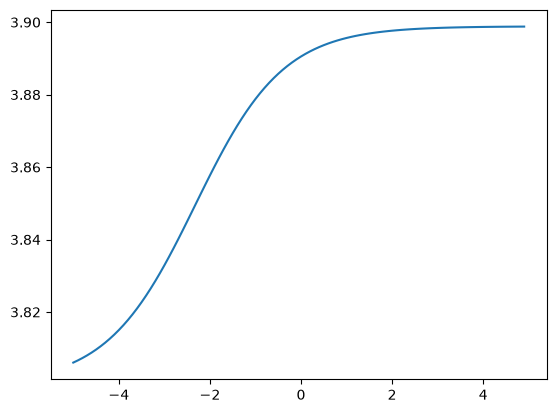

In [252]:
#işlemleri okunurluk için buraya alıyorum

layer1 = Layer(layer1_weights, layer1_biases)
layer2 = Layer(layer2_weights, layer2_biases)
layer3 = Layer(layer3_weights, layer3_biases)

test_input = [1,-2,3,4]
target=[1,0.5,-1]

layer1_forwd = layer1.forward(test_input)
layer2_forwd = layer2.forward(layer1_forwd)
predicted_output = layer3.forward(layer2_forwd)

print(f"total loss is: {loss(predicted_output,target)}")

#ağırlıklarla oynamak için aralık olarak sayılar verip her biri ile test edelim

weight_values = np.arange(-5, 5, 0.1)
losses = []
for nmb in weight_values:
    layer1.neurons[0].weights[0] = nmb
    layer1_forwd = layer1.forward(test_input)
    layer2_forwd = layer2.forward(layer1_forwd)
    predicted_output = layer3.forward(layer2_forwd)
    losses.append(loss(predicted_output, target))

plt.plot(weight_values, losses)

In [253]:
#loss hesabı için hızlandırıcı bir metot
def loss_comp(layer_list, inputs, target):
    computed_fwd = inputs
    for layer in layer_list:
        computed_fwd = layer.forward(computed_fwd)
    return loss(computed_fwd, target)

In [256]:
#test
test_input = [1,-2,3,4]
target=[1,0.5,-4]
layer_list=[layer1,layer2,layer3]
loss_comp(layer_list,test_input, target)

24.39472373849456

In [257]:
#slope hesaplama

h = 0.01

current = layer1.neurons[0].weights[0]

loss_crrnt = loss_comp(layer_list,test_input, target)

layer1.neurons[0].weights[0] = current + h

loss_next = loss_comp(layer_list,test_input, target)

slope = (loss_next - loss_crrnt) / h

slope

0.00012744155384325495

In [245]:
#sayısal türev ile gradient descent metodu
def gradient_descent(layer_list, inputs, target, learning_rate=0.1, h=0.0001, max_iterations=10000):
    loss_history = []
    for i in range(max_iterations):
        current = layer1.neurons[0].weights[0]
        loss_now = loss_comp(layer_list, inputs, target)
        layer1.neurons[0].weights[0] = current + h
        loss_next = loss_comp(layer_list, inputs, target)
        slope = (loss_next - loss_now) / h
        layer1.neurons[0].weights[0] = current - learning_rate * slope
        loss_history.append(loss_now)
    return loss_history

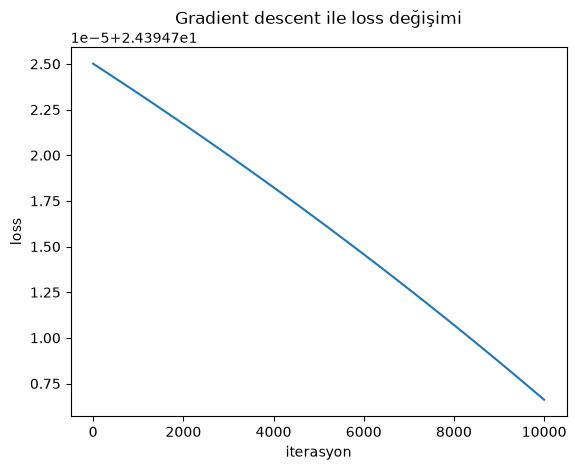

iterasyon sayısı: 10000
ilk loss: 24.394725012910097
son loss: 24.39470661382641


In [258]:
#gradient descent testi
history = gradient_descent(layer_list, test_input, target,h=0.001)

plt.plot(history)
plt.xlabel("iterasyon")
plt.ylabel("loss")
plt.title("Gradient descent ile loss değişimi")
plt.show()

print(f"iterasyon sayısı: {len(history)}")
print(f"ilk loss: {history[0]}")
print(f"son loss: {history[-1]}")